### Objective

Create a small set of visualizations to understand the structure and quality of the raw dataset.
These plots provide visual evidence for our numerical data-quality analysis and help identify patterns, distributions, and potential anomalies.
The visualizations will also serve as a baseline for comparing the dataset before and after cleaning.
No cleaning or data modification is performed in this notebook.

```text
Phase 3B – Data Quality Visualization
│
├── Setup & Load Data
│
├── Plot 1 – Trip Duration Distribution
├── Plot 2 – Trip Duration Box Plot
├── Plot 3 – Passenger Count Distribution
├── Plot 4 – Geographic Scatter Plot
├── Plot 5 – Numerical Correlation Heatmap
│
└── Visual Analysis Summary
```

## 1. Setup and Load Data

We use the complete raw TRAIN dataset because `trip_duration` is available only in TRAIN and is the target variable.

This notebook performs visualization only. No cleaning, filtering, or feature engineering is applied to the data.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
train = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "train.csv")

print("Dataset loaded successfully.")
print("Rows   :", f"{len(train):,}")
print("Columns:", len(train.columns))

train.head()

Dataset loaded successfully.
Rows   : 1,458,644
Columns: 11


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


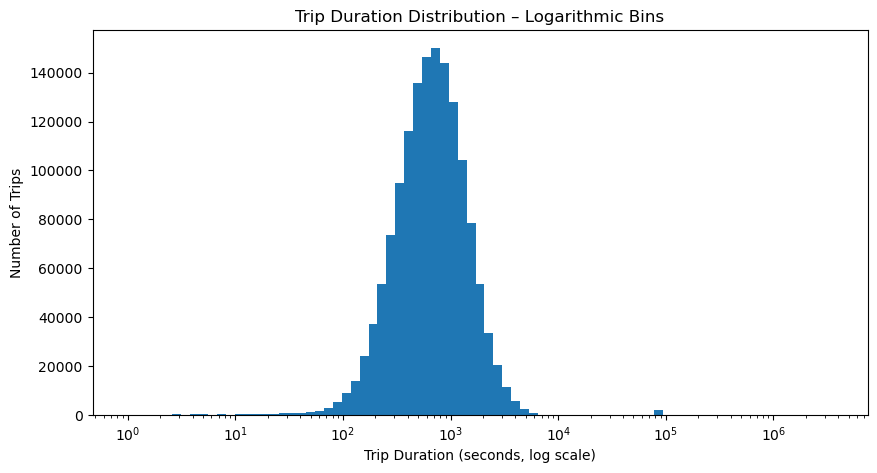

In [6]:
# Plot 1 – Trip Duration Distribution using Logarithmic Bins

duration = train["trip_duration"]

# Create logarithmically spaced bins
log_bins = np.logspace(
    np.log10(duration.min()),
    np.log10(duration.max()),
    80
)

plt.figure(figsize=(10, 5))

plt.hist(duration, bins=log_bins)

plt.xscale("log")

plt.title("Trip Duration Distribution – Logarithmic Bins")
plt.xlabel("Trip Duration (seconds, log scale)")
plt.ylabel("Number of Trips")

plt.show()

### Observation

The logarithmic-bin histogram shows that most trip durations are concentrated around a few hundred to a few thousand seconds, while a very small number of extreme durations form a long right tail.

This visually supports our earlier findings:
- **Step 3.8 – Target Distribution:** `trip_duration` has extreme right skewness (343.16).
- **Step 3.9 – Extremely Short Trips:** 8,777 trips have duration ≤ 60 seconds.
- **Step 3.10 – Extremely Long Trips:** a small number of extreme-duration trips exist, including 4 multi-day trips.

The visualization confirms that the target distribution is highly concentrated in normal trip durations with a small but significant extreme tail.

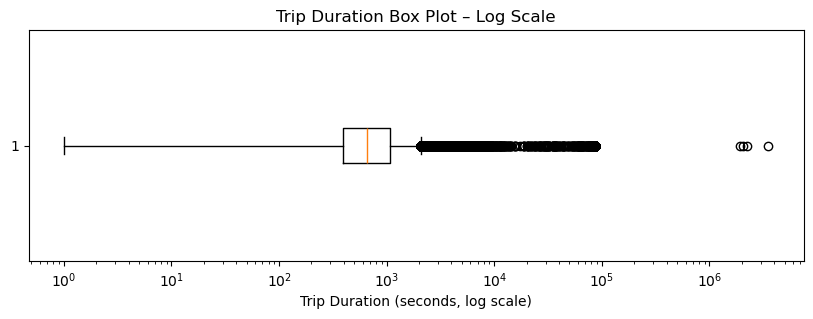

In [8]:
## Plot 2 – Trip Duration Box Plot (Log Scale)

plt.figure(figsize=(10, 3))

plt.boxplot(train["trip_duration"], vert=False)

plt.xscale("log")

plt.title("Trip Duration Box Plot – Log Scale")
plt.xlabel("Trip Duration (seconds, log scale)")

plt.show()

### Observation

The log-scale box plot shows that the majority of trip durations are concentrated in the normal range, with the median around several hundred seconds. A large number of observations extend beyond the upper whisker, confirming the presence of a substantial right-side outlier population.

This supports **Step 3.4 – Statistical Outlier Analysis**, where 74,220 records (5.09%) were identified as IQR outliers for `trip_duration`. The extreme points also align with the long-duration issues investigated in **Step 3.10**.

> The presence of statistical outliers does not automatically mean that these records are invalid; domain-based analysis is required before cleaning.

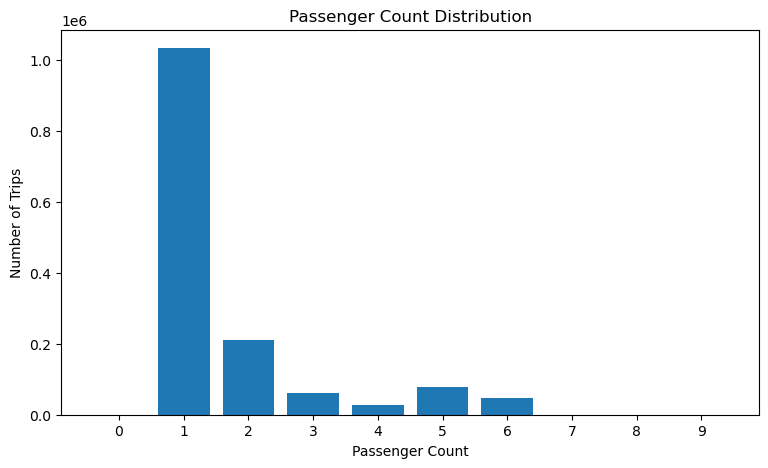

In [9]:
## Plot 3 – Passenger Count Distribution

passenger_counts = train["passenger_count"].value_counts().sort_index()

plt.figure(figsize=(9, 5))

plt.bar(passenger_counts.index.astype(str), passenger_counts.values)

plt.title("Passenger Count Distribution")
plt.xlabel("Passenger Count")
plt.ylabel("Number of Trips")

plt.show()

### Observation

The passenger-count distribution is heavily concentrated at **1 passenger**, followed by 2 passengers. Counts from 3–6 passengers occur less frequently, while `0`, `7`, `8`, and `9` passengers are extremely rare.

This visually supports **Step 3.11 – Unrealistic Passenger Counts**, where 60 TRAIN records were found with `passenger_count = 0` and only 5 records had values greater than 6. No negative passenger counts were observed.

The distribution confirms that the normal passenger-count range is predominantly **1–6 passengers**, while the rare values require separate validation rather than automatic removal.

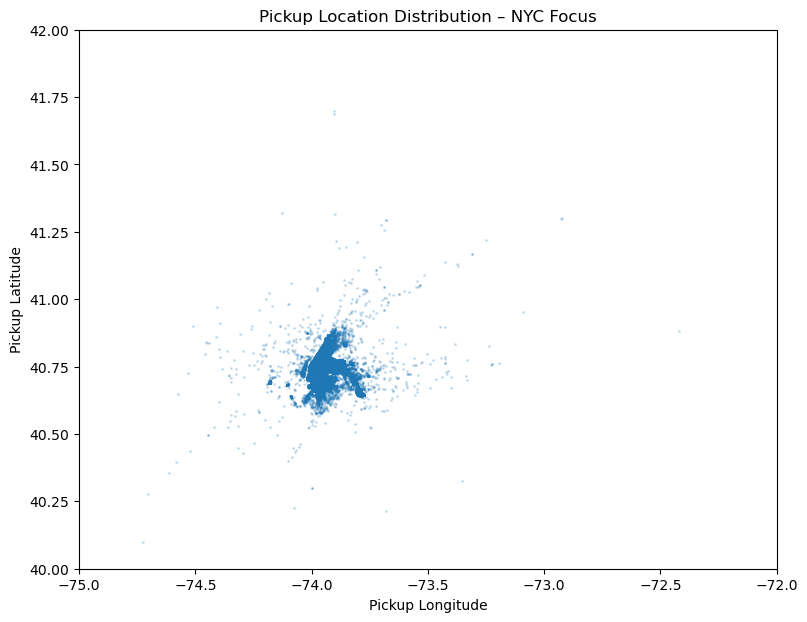

In [11]:
## Plot 4 – Geographic Distribution (NYC Focus)

plt.figure(figsize=(9, 7))

plt.scatter(
    train["pickup_longitude"],
    train["pickup_latitude"],
    s=1,
    alpha=0.2
)

# Focus on the main NYC geographic area
plt.xlim(-75, -72)
plt.ylim(40, 42)

plt.title("Pickup Location Distribution – NYC Focus")
plt.xlabel("Pickup Longitude")
plt.ylabel("Pickup Latitude")

plt.show()

### Observation

The NYC-focused scatter plot shows that the overwhelming majority of pickup locations are concentrated within a relatively small geographic area around New York City, while a smaller number of points are dispersed farther from the main cluster.

This supports **Step 3.6 – Invalid Geographical Coordinates**, where only 38 TRAIN records (0.0026%) were found outside our broad NYC bounding box. The visualization confirms that these geographically unusual observations are a very small fraction of the overall dataset.

The geographic concentration also confirms that the coordinate features contain meaningful spatial information that can be explored further during feature engineering.

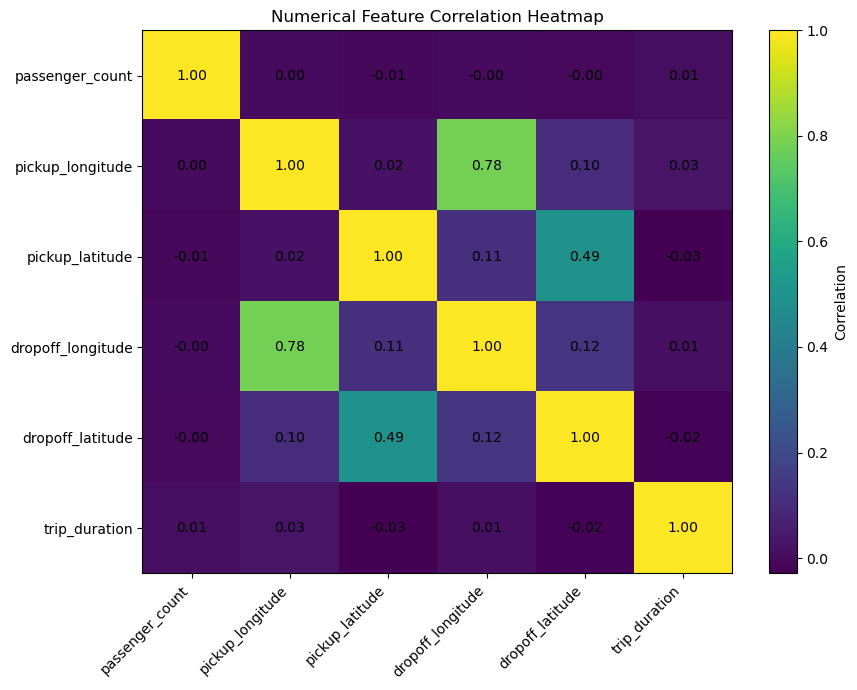

In [12]:
## Plot 5 – Numerical Correlation Heatmap

numeric_cols = [
    "passenger_count",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "trip_duration"
]

corr = train[numeric_cols].corr()

plt.figure(figsize=(9, 7))

plt.imshow(corr, aspect="auto")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(label="Correlation")
plt.title("Numerical Feature Correlation Heatmap")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

### Observation

The heatmap shows a strong positive correlation between `pickup_longitude` and `dropoff_longitude` (0.78), and a moderate correlation between `pickup_latitude` and `dropoff_latitude` (0.49), indicating that pickup and dropoff locations have meaningful geographic relationships.

However, the raw numerical features show very weak linear correlation with `trip_duration`, with correlations close to zero. This suggests that individual latitude/longitude values are not sufficient to directly explain trip duration.

This provides an early indication of why **feature engineering**, such as deriving geographic distance from pickup and dropoff coordinates, will be important later in Phase 3C.